In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import scipy

from InSitu14CO import Propagator
import Functions_14CO as F

from tqdm import tqdm

from time import time

from scipy.interpolate import interp1d

from Firn_Model import Accumulation_Site

In [2]:
def smooth_diff(f):
    return np.concatenate(( [(f[1]-f[0])], (f[2:]-f[:-2])/2, [(f[-1]-f[-2])] ), axis=0)

def efilter(x, lambd): # x cannot grow or decay faster than an exponential rate
    
    for i in range(1,len(x)):
        if x[i]/x[i-1] > np.exp(1/lambd[i-1]):
            x[i] = x[i-1]*np.exp(1/lambd[i-1])
        elif x[i]/x[i-1] < np.exp(-1/lambd[i-1]):
            x[i] = x[i-1]*np.exp(-1/lambd[i-1])
    return x

def cum_mat_prod(A,N):
    # A can have any shape, as long as the last 2 axes are square
    A_cum = np.ones((N,*A.shape))
    A_cum[0] = np.identity(A.shape[-1])
    for i in tqdm(range(1,N)):
        A_cum[i] = A @ A_cum[i-1]
    return A_cum

In [3]:
def get_ref_grids(age_file, dens_file, IceEq=True):
    
    if IceEq:
        # read ice-eq-depth file
        ice_eq_depth = pd.read_csv(dens_file)
        real_z = np.array(ice_eq_depth['z']) # meters
        ice_eq_z = np.array(ice_eq_depth['ice_eq_z']) # meters (ice-eq) aka mass-depth / ice density
        
        # ice-eq-depth file assumes a rho_ice that isn't necessarily the same one we're using.
        rho_ice = 0.9239 # Check if this is the right density to use for this file
        h_z = ice_eq_z*rho_ice
        rho = smooth_diff(ice_eq_z)/smooth_diff(real_z) * rho_ice
    else:
        # read density file
        density_scale = pd.read_csv(dens_file)
        real_z = np.array(density_scale['z']) # meters
        rho = np.array(density_scale['rho']) # 
        #h_grid = np.append(rho[0]*real_z[0],np.cumsum((rho[:-1]+rho[1:])/2*np.diff(real_z)))
        h_z = scipy.integrate.cumulative_trapezoid(rho, dx=np.diff(real_z)[0], initial=0) # assumes dz constant
    
    if age_file is None:
        return None, None, real_z, h_z, rho
    else:
        age_scale = pd.read_csv(age_file)
        ages = np.array(age_scale['ages']) # years
        depths_real = np.array(age_scale['depths_real']) # meters
        
        cut_za = depths_real <= max(real_z)
        cut_zh = real_z <= max(depths_real)
        
        #if np.sum(cut_za)>np.sum(cut_zh): # higher resolution on age scale
            #z_grid = depths_real[cut_za]
            #h_grid = np.interp(z_grid, real_z, h_z)
            #age_grid = ages[cut_za]
            #rho = np.interp(z_grid, real_z, rho)
        #else: # higher resolution on density scale
        z_grid = real_z[cut_zh]
        h_grid = h_z[cut_zh]
        age_grid = np.interp(z_grid, depths_real, ages)
        rho = rho[cut_zh]
    
    return depths_real, ages, real_z, h_z, rho

# Overview

# Configuration Parameters

In [4]:
Load_Mat = True
if Load_Mat:
    runMat = scipy.io.loadmat('matlab/Firn Ice Model/Firn Model - CIC Forward Model v5.0/Runs/Run2026-07-21_08h59m.mat')
    runMat

In [5]:
# Depth & Age Reference Grids

age_file = 'DomeC_age_scale_Apr2023.csv' # sets depth-ice age conversion

dens_file = 'Real_vs_ice_eq_depth.csv' # sets density profile & real-to-ice-eq depth conversion
IceEq = True # dens_file contains ice-equivalent depths?  else dens_file contains density profile

# setup depth & age reference grids
depths_real, ages, real_z, h_z, rho_z = get_ref_grids(age_file, dens_file, IceEq)

cut_zh = real_z <= max(depths_real)
z_grid = real_z[cut_zh]
h_grid = h_z[cut_zh]
age_grid = np.interp(z_grid, depths_real, ages)
rho = rho_z[cut_zh]

grid = {'z':z_grid, 'h':h_grid, 'age':age_grid}

In [6]:
# Firn Site Properties

L = np.array([1, 7e-4]) # Ice Grain Leakage Rates (yr^-1)
if Load_Mat:
    L = runMat['leakage'][0,0]['closed'][0,:2]
    
Acc = 0.033# Accumulation rate (m.w.e./yr)
if age_file is None:
    age_grid = h_grid/Acc
else: # this will be set later
    Acc = None
    
rho_co = 0.833 # density at close off depth? idk

R = 8.314472 # gas constant (J/mol K)
g = 9.82 # gravity (m/s^2)
T = -54 + 273.15 # Temperature (Kelvins)
pressure = 65800 # air pressure (Pa)
M_air = 28.96e-3 # molar mass of air (kg/mol)

D_0eddy = 2.55e-5 # convective diffusivity const.
H_eddy = 3 #1/e depth of convective layer

In [7]:
# Gas Properties

D_ref_CO2 = 5.75e-10 * T**1.81 * 101325 / pressure # CO2 diffusivity

M_trace = 30e-3 # molar weight [kg/mol]
D_trace = D_ref_CO2 * 1.25 * 0.9829926 # free air diffusivity w/ “sqrt of ratio of reduced masses”
lambd = 1.216e-4
L_trace = lambd/(60*60*24*365.25)

In [8]:
# Grid / Bin Ranges & Resolutions

z_end = 120 # max depth of calculation (m)
z_end = min(z_end, z_grid[-1])

t_D_max = 1000 # max diffusion time (yrs) # At Dome_C, ~1e-12 14CO remains in open firn after 1000 yrs
t_end = np.interp(z_end, z_grid, age_grid) + t_D_max # max time of calculation (yrs)
h_end = np.interp(z_end, z_grid, h_grid) # max water-eq-depth of calculation (m.w.e.)

if Load_Mat:
    t_end = runMat['t_end'][0,0]

# time resolutions [yrs]
# production time resolution
dt_P = 20
# atmospheric time resolution
dt_atm = 10
# accumulation time resolution
dt_A = 0.5
# diffusion time resolution
dt_D = 0.01
# dt_P & dt_atm should be divisible by dt_A
# dt_A should be divisible by dt_D

# diffusion depth resolution [m]
dz_D = 0.25

# custom set production depth grid
p_scale = 'h'
dp = 1
p_base = np.arange(int(grid[p_scale][-1]/dp)+1)*dp

# custom set final depth grid
f_scale = 'z'
df = 1
f_base = np.arange(int(grid[f_scale][-1]/df)+1)*df

sample_file = 'DomeC 14CO data analysis current.xlsx'
sample_w = 20

In [9]:
Copy_Firn = True

if Copy_Firn:
    if Load_Mat:
        Site = Accumulation_Site(z_end=runMat['z_end'][0,0],
                                   t_end=runMat['t_end'][0,0],
                                   C14CO_const=int(runMat['C14CO_const'][0,0]),
                                   Acc=runMat['Acc'][0,0],
                                  )
    else:
        Site = Accumulation_Site()

    # caculate cosmogenic 14C in reservoirs w/ Leakage rates L
    C14_grains, C14_leak_open, C14_leak_closed, C14_cumuleak_closed = Site.Calc_14C_ice(L=L)

    # calculate 14CO concentrations in open porosity, + concentration trapped into closed porosity
    C14_open_gas, C14_closed_gas, C14_open_atm, C14_closed_atm, c_gases = Site.Calc_profiles(C14_leak_open, analytic=True)

/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:219: RuntimeWarning: invalid value encountered in divide
  bubble_pres = np.sum((dscl * C * self.s)[None,:] * self.dz / (1+strainsum[:,None]-strainsum[None,:]) * (i[None,:]<=i[:,None]), axis=-1)/(self.s*(self.s_closed-self.s_closed[0]))
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:359: RuntimeWarning: divide by zero encountered in log
  Lrate = -np.log(1-L)
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:361: RuntimeWarning: invalid value encountered in multiply
  Ctemp = np.exp(-(lambd+Lrate)*(COS_age+COS_dt)) * np.cumsum((COS_P).reshape((-1,3,1)) * np.exp((lambd+Lrate)*COS_age) * COS_dt, axis=0)
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:597: RuntimeWarning: divide by zero encountered in divide
  gram_to_ppm = 1e18*Site.R*Site.T / (6.022140857e23*Site.pressure*Site.s_open/Site.rho*np.exp(Site.M_air*Site.g*Site.z/(Site.R*Site.T))*1e-6)


0.013485908508300781
interpolating...


100%|█████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 81.62it/s]

integrating...
  Calculated open and closed profiles for gas 1 out of 1
0.2632765769958496


# Grids & Bins

In [10]:
def get_bins(x):
    # returns centers and widths of bins
    x = np.array(x)
    if x.shape[0]==2: # if first axis is length 2, takes index 0 as lower bounds, index 1 as upper bounds
        return (x[0]+x[1])/2, x[1]-x[0]
    else:
        return (x[:-1]+x[1:])/2, np.diff(x,axis=0)

### Real Depth ($z$) -- Mass Depth ($h$) -- Age ($\text{age}$) Reference Grids

(441,)


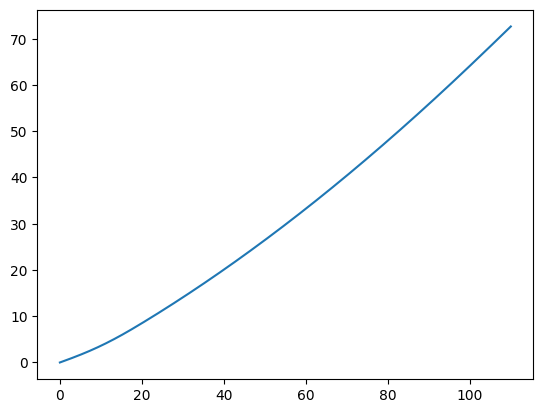

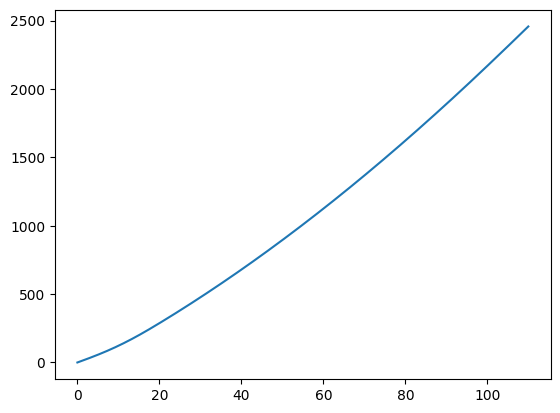

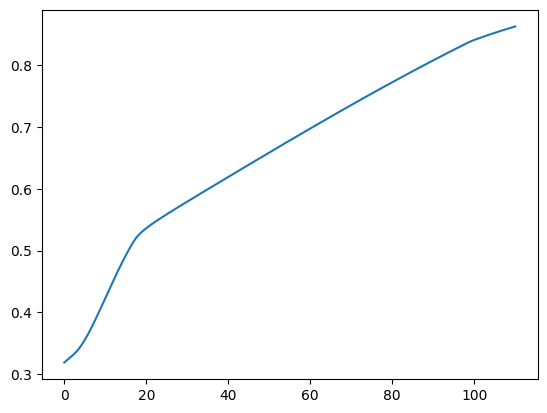

In [11]:
# age & depth interpolation grids [grid]
# equally space in age
if Copy_Firn:
    z_grid = Site.z
    h_grid = Site.IceAge * Site.Acc * Site.rho_ice
    age_grid = Site.IceAge
    rho = Site.rho
print(z_grid.shape)

grid = {'z':z_grid, 'h':h_grid, 'age':age_grid}

plt.plot(z_grid, h_grid)
plt.show()

plt.plot(z_grid, age_grid)
plt.show()

plt.plot(z_grid, rho)
plt.show()

### Production Depths ($p$), Production Times ($t_P$) & Atmospheric Times ($t_{atm}$)

In [12]:
# Production depths [grid]

p_grid = grid.get(p_scale, h_grid)

z_p = p_base if p_scale=='z' else np.interp(p_base, p_grid, z_grid)
h_p = p_base if p_scale=='h' else np.interp(p_base, p_grid, h_grid)
age_p = p_base if p_scale=='age' else np.interp(p_base, p_grid, age_grid)

age_p.shape

(256,)

In [13]:
# Production times [grid]

t_P = np.arange(int(age_grid[-1]/dt_P))*dt_P
t_P = t_P-t_P[-1]
t_P.shape

(122,)

In [14]:
# Atmospheric times [grid]

t_atm = np.arange(int(age_grid[-1]/dt_atm))*dt_atm
t_atm = t_atm-t_atm[-1]
t_atm.shape

(245,)

### Accumulation Depths ($a$) & Times ($t_A$)

In [15]:
# Accumulation Bins [bins]
# equally spaced in time / ice age
# used to track ice parcels as 14CO accumulates

if Copy_Firn:
    dt_A = Site.t_resol

t_A_bins = np.arange(int(age_grid[-1]/dt_A) + 1) * dt_A
t_A_bins = t_A_bins - t_A_bins[-1]
t_A = (t_A_bins[:-1]+t_A_bins[1:])/2

age_A_bins = np.arange(int(age_grid[-1]/dt_A) + 1) * dt_A
age_A, dage_A = get_bins(age_A_bins)
#age_A = age_A_bins[:-1]

z_A_bins = np.interp(age_A_bins, age_grid, z_grid)
z_A, dz_A = get_bins(z_A_bins)
#z_A = z_A_bins[:-1]

h_A_bins = np.interp(age_A_bins, age_grid, h_grid)
h_A, dh_A = get_bins(h_A_bins)
#h_A = h_A_bins[:-1]

age_A.shape

(4914,)

### Diffusion Depths ($d$) & Times ($t_D$)

In [16]:
dt_D

0.01

In [17]:
# Diffusion Depths [bins]
# equally spaced in z
z_D_bins = np.arange(int(z_grid[-1]/dz_D)+1)*dz_D
z_D = get_bins(z_D_bins)[0]
#z_D = z_D_bins[:-1]

h_D_bins = np.interp(z_D_bins, z_grid, h_grid)
h_D, dh_D = get_bins(h_D_bins)
#h_D = h_D_bins[:-1]

age_D_bins = np.interp(z_D_bins, z_grid, age_grid)
age_D, dage_D = get_bins(age_D_bins)
#age_D = age_D_bins[:-1]

if Copy_Firn:
    z_D = z_grid
    dz_D = smooth_diff(z_grid)
    
    h_D = h_grid
    dh_D = smooth_diff(h_grid)
    
    age_D = age_grid
    dage_D = smooth_diff(age_grid)

z_D.shape

(441,)

### Final Depths ($f$)

In [18]:
# Final Depths [bins]

if Copy_Firn:
    z_f = z_grid
    dz_f = smooth_diff(z_f)
    
    h_f = h_grid
    dh_f = smooth_diff(h_f)
    
    age_f = age_grid
    dage_f = smooth_diff(age_f)
else:
    f_grid = grid.get(f_scale, z_grid)
    
    z_f_bins = f_base if f_scale=='z' else np.interp(f_base, f_grid, z_grid)
    h_f_bins = f_base if f_scale=='h' else np.interp(f_base, f_grid, h_grid)
    age_f_bins = f_base if f_scale=='age' else np.interp(f_base, f_grid, age_grid)
    
    z_f, dz_f = get_bins(z_f_bins)
    h_f, dh_f = get_bins(h_f_bins)
    age_f, dage_f = get_bins(age_f_bins)
    
z_f.shape

(441,)

### Sample Depths ($s$)

In [19]:
pd_DomeC = pd.read_excel(sample_file, '14CO vs depth',
                         header = 2, index_col=0,
                         usecols=[0,1,2,3,5,6], skiprows=[3,16,21,22,23])
pd_DomeC

,"Mean depth, m","14CO, molec / g ice after all corrections","Error, 1 sigma","Mean gas age, yr before 1950","Mean gas age, Years before measurement date"
Sample,,,,,
14CO_UR_DC_FIRN_SAMPLE_1,34.000,46.438967,1.143309,NaN,NaN
14CO_UR_DC_FIRN_SAMPLE_2,54.500,28.289650,0.749249,NaN,NaN
14CO_UR_DC_FIRN_EXTRACTION_3,75.000,18.807095,0.543124,NaN,NaN
14CO_UR_DC_ICE_SAMPLE_1,110.000,18.669397,0.885088,434.483581,510.483581
14CO_UR_DC_ICE_SAMPLE_3,150.000,26.848805,0.679599,1901.485970,1977.485970
14CO_UR_DC_ICE_SAMPLE_4,170.000,28.480674,0.573240,2717.573599,2793.573599
14CO_UR_DC_ICE_SAMPLE_5,190.500,29.289987,0.601586,3323.027758,3399.027758
14CO_UR_DC_ICE_SAMPLE_6,211.000,29.666008,0.722400,4118.909061,4194.909061
14CO_UR_DC_ICE_SAMPLE_7,230.925,28.951245,0.655983,4761.798084,4837.798084


In [20]:
z_exp, CO_exp, dCO_exp = pd_DomeC.to_numpy()[:,:3].T
# separate samples into categories
i_samples = [0,3,12,len(z_exp)]
n_samples = ['Firn Sample', 'Borehole 1', 'Borehole 2']

In [21]:
# Sample Depths [bins]

sample_widths = np.array([sample_w]*len(z_exp)) #widths of ice core sample depth ranges [m]

z_samp_bins = z_exp[None,:] + sample_widths[None,:]*np.array([-0.5,0.5])[:,None]
z_samp, dz_samp = get_bins(z_samp_bins)

h_samp_bins = np.interp(z_samp_bins, z_grid, h_grid)
h_samp, dh_samp = get_bins(h_samp_bins)

#axis0 - Lower/Upper Bound (0-lower, 1-upper)
#axis1 - Sample bin (s)
z_samp_bins.shape

(2, 16)

## Interpolation Matrices ($\hat{\delta}$)

$\hat{\delta}_{i,j}$ - Interpolation matrix [unitless], interpolates a vector or tensor ($F_j$) defined over the input grid $\vec{x}_j$ to output grid $\vec{y}_i$, while also functioning like a Kronecker Delta s.t. $\vec{y}_i\approx\vec{x}_j$.  If the input and output grids are identical, it is the Kronecker Delta / Identity matrix $\delta_{ij} = \hat{I}_{ij}$.

$$\hat{\delta}_{ij}(\vec{y}_i,\vec{x}_j) = \begin{cases}
\displaystyle
(\vec{y}_i\geq \vec{x}_0) - (\frac{\vec{y}_i-\vec{x}_{j}}{\vec{x}_{j+1}-\vec{x}_{j}}).\text{clip}(0,1) & j=0\\
\displaystyle
(\frac{\vec{y}_i-\vec{x}_{j-1}}{\vec{x}_j-\vec{x}_{j-1}}).\text{clip}(0,1) - (\frac{\vec{y}_i-\vec{x}_{j}}{\vec{x}_{j+1}-\vec{x}_{j}}).\text{clip}(0,1) & 0<j<\text{max}\\
\displaystyle
(\frac{\vec{y}_i-\vec{x}_{j-1}}{\vec{x}_j-\vec{x}_{j-1}}).\text{clip}(0,1) - (\vec{y}_i>\vec{x}_{\text{max}}) & j=\text{max}
\end{cases}$$

$\vec{y}_i$ - output grid

$\vec{x}_j$ - input grid

Note: Values of $\vec{y}_i$ outside the range of $\vec{x}_j$ interpolate to zero ($F_i = 0$).  To set the value below or above the bounds of $\vec{x}$ equal to the boundary value, remove the ($\vec{y}_i\geq \vec{x}_0$) or ($\vec{y}_i>\vec{x}_{\text{max}}$) term respectively.

To make an edge decrease linearly to 0 beyond the boundaries of $\vec{x}$, append an extra value at the start or end of the input vector $\vec{x}$, calculate the matrix, then remove the corresponding column from the matrix.

In [22]:
def interp_mat(out, grid_in): # interpolates from grid_in to out
    # input arrays must have broadcastable shape
    # grid's primary index should be along axis -1
    
    # slope from 0 to 1 as x passes from lower to upper bound
    slope = ((out[...,:-1 if out.shape[-1]>1 else None]-grid_in[...,:-1])/np.diff(grid_in,axis=-1)).clip(0,1)
    return np.concatenate(
        [1*(out[...,:1]>=grid_in[...,:1])-slope[...,:1],
         -np.diff(slope, axis=-1),
         slope[...,-1:]-1*(out[...,-1:]>grid_in[...,-1:])],
        axis=-1)

## Sample Average Matrices ($\hat{S}$)

$\hat{S}$ - sample operator [unitless], averages over each sample depth range in accumulation depth

$$S(s,h) = \frac{(s^+ - h^-).\text{clip}(0,\Delta h) - (s^- - h^-).\text{clip}(0,\Delta h)}{\sum_h (s^+ - h^-).\text{clip}(0,\Delta h) - (s^- - h^-).\text{clip}(0,\Delta h)}$$

$s$ - Output bins (+ upper bound, - lower bound)

$h$ - Input bins (- lower bound, $\Delta$ width)

In [23]:
def bin_average_mat(out_up, out_low, in_low, din):
    S = (out_up-in_low).clip(0,din) - (out_low-in_low).clip(0,din)
    return S/np.sum(S, axis=-1, keepdims=True)

## Input Vectors

### $^{14}$CO Production Rates ($\vec{P}$)

In [24]:
COS_partition = np.array(
    [#CO2         CO          CH4
    [0.686307104, 0.31125305, 0.002439846], # neutron
    [0.686307104, 0.31125305, 0.002439846], # neg muon
    [0.686307104, 0.31125305, 0.002439846], # fast muon
])
if Load_Mat:
    COS_partition = runMat['COS_partition']

f_factors = np.array([1., 0.06, 0.08])
P0_tuning = f_factors / np.array([1, COS_partition[0,1], COS_partition[0,1]]) * COS_partition[0,1]
if Load_Mat:
    P0_tuning = runMat['P0_tuning'][0] * COS_partition[0,1]
    f_factors = P0_tuning * np.array([1/COS_partition[0,1], 1, 1])
f_factors

array([1.03 , 0.065, 0.07 ])

In [25]:
def COS_Production(h, scaling_site = [16.95], P0_tuning = np.ones(3), pressure=pressure):
    Pn0_SLHL = 12.76 # Borchers ‘16
    QtzToIce = 60.08 / 2 / 18.02 # conversion for O-atom density difference between quartz and ice

    Pn = Pn0_SLHL * QtzToIce * scaling_site[0] * P0_tuning[0] * np.exp(-100 * h /150)

    Balco_mu_neg, Balco_mu_fast = F.Balco_P_mu_total(100*h, pressure/100)

    Pmu = Balco_mu_neg * P0_tuning[1]
    Pmuf = Balco_mu_fast * P0_tuning[2]

    return Pn, Pmu, Pmuf

In [26]:
delta_pA = interp_mat(h_p[:,None],np.array([0,*h_A])[None,:])[:,1:]
delta_Ap = interp_mat(h_A[:,None],h_p[None,:])
cut = np.arange(len(h_p))[np.sum(delta_pA,axis=1)>0][-1]+1
delta_Ap_inv = np.linalg.inv(delta_Ap[:,:cut].T @ delta_Ap[:,:cut]) @ delta_Ap[:,:cut].T
delta_Ap_inv = np.concatenate((delta_Ap_inv, np.zeros((len(h_p)-cut,len(h_A)))), axis=0)

(1e-05, 200.0)

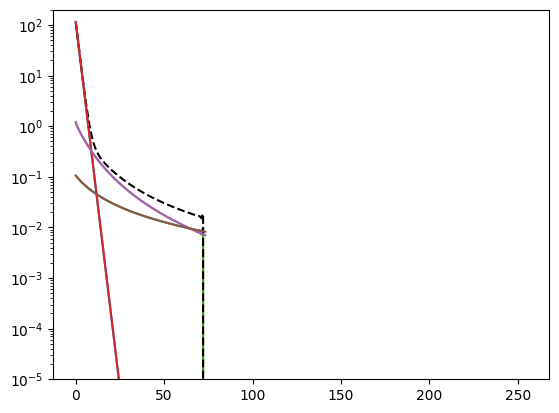

In [27]:
# Production Rates [grid]
P_true = np.array(COS_Production(h_A))
#P_m = np.array(COS_Production(p))
P_m = P_true @ delta_Ap_inv.T
P = P0_tuning @ P_m
plt.plot(h_p, (P0_tuning[:,None]*P_m).T)
plt.plot(h_p, P, ls='--', c='k')
if Load_Mat:
    plt.plot(runMat['COS_z']*runMat['rho_ice'], COS_partition[0,1]*runMat['COS_Pn'][:,-1])
    plt.plot(runMat['COS_z']*runMat['rho_ice'], COS_partition[0,1]*runMat['COS_Pmu'][:,-1])
    plt.plot(runMat['COS_z']*runMat['rho_ice'], COS_partition[0,1]*runMat['COS_Pmuf'][:,-1])
plt.yscale('log')
plt.ylim(1e-5,2e2)

### CR Flux History ($\vec{\phi}$)

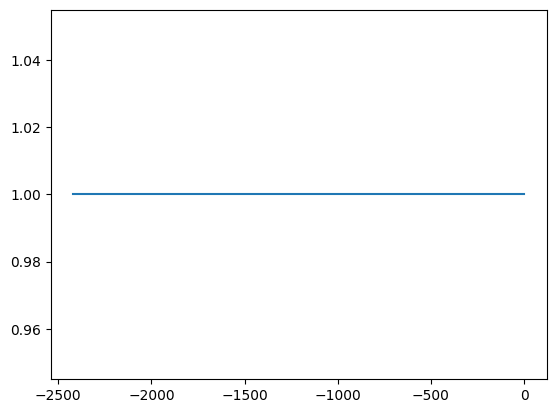

In [28]:
# GCR Flux History
phi = np.ones(len(t_P))
plt.plot(t_P, phi)

### Reservoir Partitions ($\vec{R}_r$)

In [29]:
Res = np.array([1-1e-2, 1e-2])
Res /= np.sum(Res)
if Load_Mat:
    Res = runMat['Res_partition'][0]
Res

array([0.9956, 0.0044])

### Atmospheric $^{14}$CO History ($\vec{C}^{\text{atm}}$)

In [30]:
def C14_unit_convert(C14_in,unit_in,unit_out):#,date,d13C,MixR):
    # Constants
    Navo = 6.022140857E23
    scc_mol = 22414
    Aabs = 1.1764E-12
    tau = 8267
    
    # molec/ccSTP --> ppmE-12
    if (unit_in=='molec' and unit_out=='ppm'):
        return C14_in * scc_mol / Navo * 10**18

    # ppmE-12 -> molec/ccSTP
    if (unit_in=='ppm' and unit_out=='molec'):
        return C14_in / scc_mol * Navo / 10**18

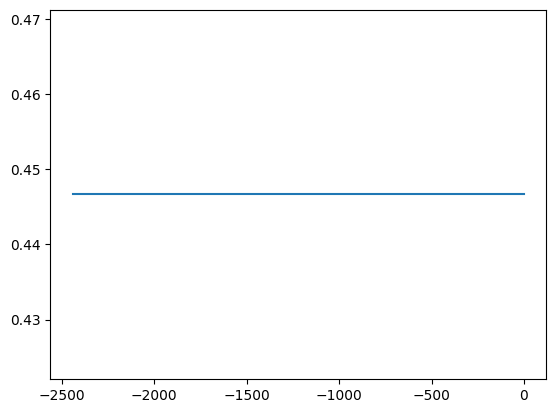

In [31]:
# Atmospheric 14CO history
C14CO_const = 12 # constant 14CO history (molec/ccSTP)
if Load_Mat:
    C14CO_const = int(runMat['C14CO_const'][0,0])

gas_history = C14_unit_convert(C14CO_const, 'molec', 'ppm') * np.ones(len(t_atm))
plt.plot(t_atm, gas_history)

# Firn Site Functions & Operators

## Porosity ($s$)

Define the ice density profile of Dome C and the open, closed, total porosity $s$ with depth.

$$\rho(z) = dh(z)/dz$$

$$s(z) = 1-\rho(z)/\rho_{ice}$$

$$s_c(z) = 0.37s(z) * (\frac{s(z)}{1-\rho_{co}/\rho_{ice}})^{-7.6}$$

$$s_o(z) = s(z) - s_c(z)$$

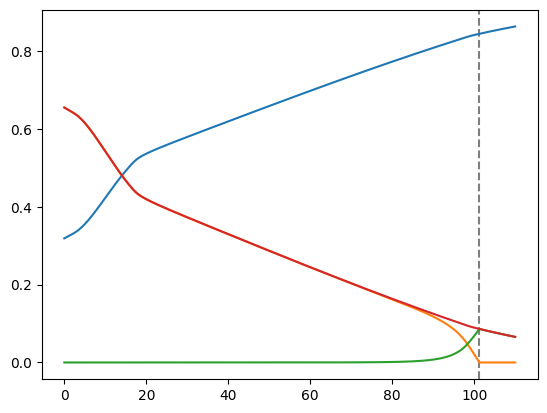

In [32]:
# Calculate Densities and Porosities

rho_ice = max(0.9165 - (T-273.15)*1.4438e-4 - (T-273.15)**2 * 1.5175e-7, max(rho)+1e-6) # Schwander et al.
if Copy_Firn:
    rho_ice = Site.rho_ice

s = 1 - rho/rho_ice # porosity of ice by depth
s_closed = (0.37 * s * (s/(1-rho_co/rho_ice))**(-7.6)).clip(max=s) # closed porosity
s_open = s - s_closed # open porosity

teller_co = np.argmax(s_closed) # depth index of maximum closed porosity (close off depth??)

plt.axvline(z_grid[teller_co], ls='--', c='k', alpha=0.5)
plt.plot(z_grid,rho)
plt.plot(z_grid,s_open)
plt.plot(z_grid,s_closed)
plt.plot(z_grid,s)

## Inverse Tortuosity & Diff_m

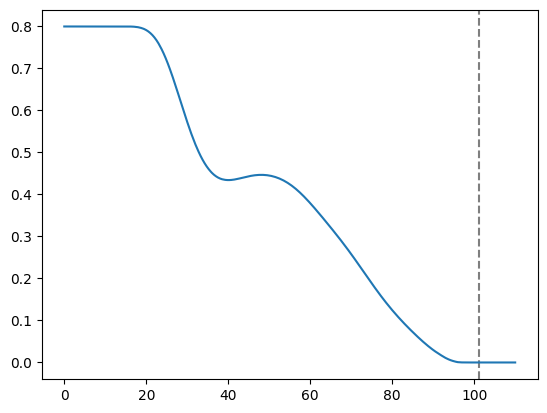

In [33]:
# Load InvTort and Diff_m from csv

tort_file = 'Firn_Model_Tortuosity_DomeC.csv'
Profiles = np.array(pd.read_csv(tort_file))
InvTort = np.interp(z_grid, Profiles[:,0], Profiles[:,1]) # inverse Tortuosity D(z) = D^0 * Inv tort
Diff_m = np.interp(z_grid, Profiles[:,0], Profiles[:,2]) # dispersive mixing in lock-in zone

plt.axvline(z_grid[teller_co], ls='--', c='k', alpha=0.5)
plt.plot(z_grid, InvTort)

## Bubble Pressure ($b_p$) & Velocity ($v$)

$$v_{ice}(z) = dz/dage = Acc/\rho$$

In the firn, we calculate the bubble pressure by the integral:

$$b_p(z) = \frac{\int_0^z \frac{ds_c(z')}{dz'}e^{M_{air}g z'/RT} s(z')/ (1+\int_{z'}^z \frac{d\ln v_{ice}(z'')}{dz''} dz'')dz'}{s(z)\int_0^z \frac{ds_c(z')}{dz'} dz'} $$

I can't help but notice we're taking the integral of derivatives here.  Makes it pretty easy to simplify,

$$b_p(z) = \frac{\int_0^z \frac{ds_c(z')}{dz'}e^{M_{air}g z'/RT} s(z') /(1+\ln v_{ice}(z) - \ln v_{ice}(z'))dz'}{s(z)[s_c(z)-s_c(0)]}$$

We also calculate the flux of air through the close-off depth:

$$flux = b_p(z_{co+1}) s_c(z_{co+1}) v_{ice}(z_{co+1})$$

The velocity:

$$v(z) = \begin{cases}\displaystyle
\frac{flux - v_{ice} * b_p * s_c}{C * s_o} & <v_{ice}(z)\\
v_{ice}(z) & \text{else}
\end{cases}$$

And the air content:

$$a_c = 1000 * \frac{b_p(z_{co+1}) * s_c(z_{co+1})}{\rho(z_{co+1})} * \frac{pressure}{101325} * \frac{273.15}{T}$$

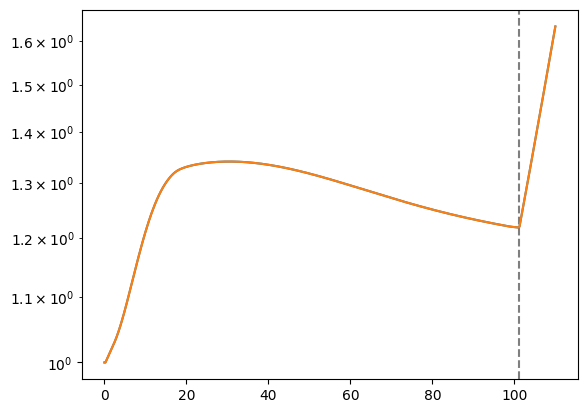

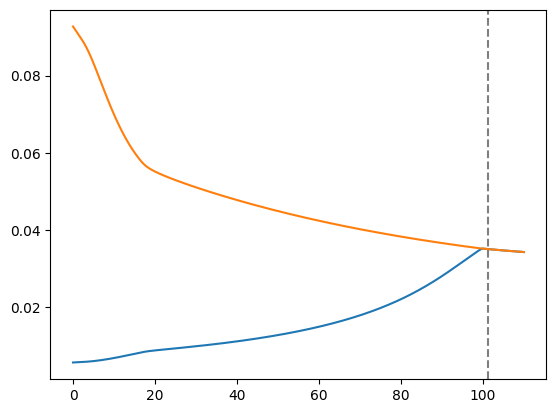

In [34]:
dz_grid = smooth_diff(z_grid)

#dscl = smooth_diff(s_closed)/dz # ds_closed / dz
dscl = np.diff(s_closed, prepend=s_closed[0])/dz_grid # ds_closed / dz

C_air = np.exp(M_air * g * z_grid / (R * T) )
if Acc is None:
    Acc = h_grid[teller_co]/age_grid[teller_co]
v_ice = Acc / rho # downwards ice velocity

#strain = smooth_diff( np.log(v_ice))/dz # d log(v_ice) / dz
#strainsum = scipy.integrate.cumulative_trapezoid(strain, dx=self.dz, initial=0)
strainsum = np.log(v_ice)
i = np.arange(len(z_grid))
bubble_pres = np.sum((dscl * C_air * s * dz_grid)[None,:] / (1+strainsum[:,None]-strainsum[None,:]) * (i[None,:]<=i[:,None]), axis=-1)/(s*(s_closed-s_closed[0]).clip(min=1e-20))
# Divide by zero error at the first index, so we set that to 1
bubble_pres[0] = 1 # what are the units here??
# Answer: it's relative to surface pressure

# After teller_co:
bubble_pres[teller_co+1:] = bubble_pres[teller_co] * s[teller_co] / s[teller_co+1:] * v_ice[teller_co] / v_ice[teller_co+1:]
# bubble pres is directly inverse to s and v_ice below close-off depth

flux = v_ice[teller_co+1] * bubble_pres[teller_co+1] * s_closed[teller_co+1]

velocity = np.minimum(v_ice, (flux + 1e-10 - v_ice * bubble_pres * s_closed) / ((s_open + 1e-10) * C_air) )
#velocity = velocity/(60*60*24*365.25) # convert to m/s

#never used:
#air_content = 1000 * bubble_pres[teller_co+1] * s_closed[teller_co+1] * pressure / 101325 * 273.15 / T / rho[teller_co+1]

plt.axvline(z_grid[teller_co], ls='--', c='k', alpha=0.5)
plt.plot(z_grid, bubble_pres)
if Copy_Firn:
    plt.plot(Site.z, Site.bubble_pres)
plt.yscale('log')
plt.show()

plt.axvline(z_grid[teller_co], ls='--', c='k', alpha=0.5)
plt.plot(z_grid, velocity)#*(60*60*24*365.25))
#plt.plot(z, (flux + 1e-10 - v_ice * bubble_pres * s_closed) / ((s_open + 1e-10) * C_air))
plt.plot(z_grid, v_ice)
#plt.plot(z, Dome_C.v_ice)
plt.show()

## Diffusion Matrix ($D$)

### Crank-Nicholson Parameters ($\alpha$, $\beta$, $\gamma$)

The differential equation describing the diffusion of our open porosity gas concentration $c$ is:

$$\frac{\partial c}{\partial t} = \alpha\frac{\partial^2 c}{\partial z^2} + \beta\frac{\partial c}{\partial z} + \gamma c$$

where

$$\alpha = D + D_e$$

$$\beta = \frac{[D*(M_{air}-M_{^{14}CO}) + D_e*M_{air}]*g}{R*T} + \frac{d((D+D_e)*C_{air}*s_o)}{s_o*C_{air}\,dz} - v$$

$$\gamma = \frac{d(D*C_{air}*s_o)}{s_o*C_{air}\,dz}\frac{(M_{air}-M_{^{14}CO})*g}{R*T} - \lambda$$

$D = InvTort * D_{trace}$ - Diffusivity

$D_e$ - Eddie diffusivity

$C_{air} = e^{M_{air}gz/RT}$ - "Barometric equation", open porosity pressure relative to surface, I think?

$M_{air}$ - molar mass of air

$M_{trace}$ - molar mass of $^{14}$CO

$L_{trace}$ - decay rate of $^{14}$CO

The function below calculates $\alpha' = \alpha \frac{dt}{2dz^2}$, $\beta' = \beta \frac{dt}{4dz}$, and $\gamma' = \gamma \frac{dt}{2}$, for reasons that will be explained in the following section.

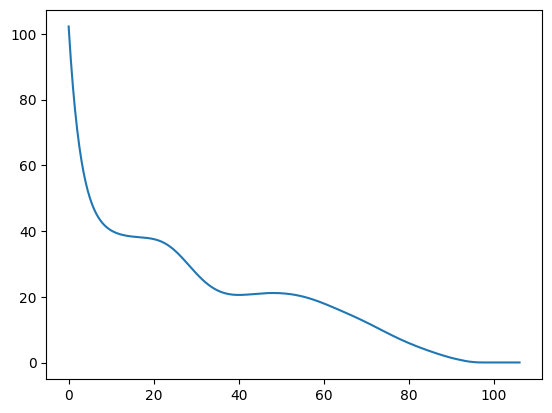

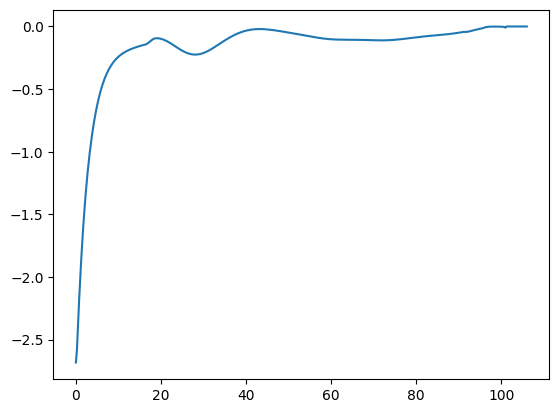

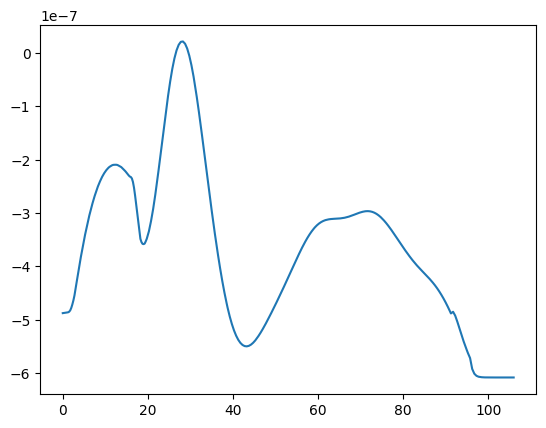

In [35]:
Q = np.arange(len(z_D))[z_D<=z_grid[teller_co+20]][-1]

Diff   =  InvTort * D_trace

# Eddy diffusivity part:
Diff_e = efilter(D_0eddy*np.exp(-z_grid/H_eddy),0.5/np.diff(z_grid))*(z_grid<55) # Convection following Kawamura et al
Diff_e = np.maximum(Diff_e, Diff_m)    # Add dispersion in the LIZ

# Take the derivatives
porecl = smooth_diff(Diff*C_air*(s_open+1e-9))/dz_grid/((s_open+1e-9)*C_air)#.clip(min=1e-20)
porecl_e = smooth_diff(Diff_e*C_air*(s_open+1e-9))/dz_grid/((s_open+1e-9)*C_air)#.clip(min=1e-20)

porecl[teller_co]   = porecl[teller_co+1]
porecl_e[teller_co] = porecl_e[teller_co+1]

# c_t = alpha*c_zz + beta*c_z + gamma*c

alpha =  (dt_D*60*60*24*365.25/2/dz_D**2) * np.interp(z_D, z_grid, Diff+Diff_e)
beta  =  (dt_D*60*60*24*365.25/4/dz_D) * np.interp(z_D, z_grid, Diff*(M_air-M_trace)*g/(R*T) + (Diff_e)*(M_air)*g/(R*T) + porecl + porecl_e -velocity/(60*60*24*365.25))
gamma =  (dt_D*60*60*24*365.25/2) * np.interp(z_D, z_grid, porecl*(M_air-M_trace)*g/(R*T) +  -L_trace)

plt.plot(z_grid[:Q], alpha[:Q])
plt.show()

plt.plot(z_grid[:Q], beta[:Q])
plt.show()

plt.plot(z_grid[:Q], gamma[:Q])
plt.show()

### Crank-Nicholson Matrices

To solve the diffusion PDE:

$$\frac{\partial}{\partial t}c = \alpha\frac{\partial^2}{\partial z^2}c + \beta\frac{\partial}{\partial z}c + \gamma c$$

We approximate our spatial derivates as the average between timesteps $t+1$ and $t$:

$$\frac{c^{t+1}-c^t}{\Delta t} = \frac{\alpha}{2(\Delta z)^2}((c^{t+1}_{i+1}-2c^{t+1}_i+c^{t+1}_{i-1})+(c^t_{i+1}-2c^t_i+c^t_{i-1})) + \frac{\beta}{4\Delta z}((c^{t+1}_{i+1}-c^{t+1}_{i-1})+(c^t_{i+1}-c^t_{i-1})) + \frac{\gamma}{2}(c^{t+1}_i + c^{t}_i)$$

Moving our timesteps $t+1$ and $t$ to opposite sides of the equation,

$$-(\alpha' + \beta')c^{t+1}_{i+1} + (1 + 2\alpha' - \gamma')c^{t+1}_i - (\alpha' - \beta')c^{t+1}_{i-1} = (\alpha' + \beta')c^{t}_{i+1} + (1 - 2\alpha' + \gamma')c^{t}_i + (\alpha' - \beta')c^{t}_{i-1}$$

We can rewrite this as a matrix product on $c^{t+1}$ and $c^t$:

$$A_{i,i-1} = \alpha'_i - \beta'_i; \quad A_{i,i} = -2\alpha'_i + \gamma'_i; \quad A_{i,i+1} = \alpha'_i + \beta'_i$$

$$(I-A)c^{t+1} = (I+A)c^t$$

Which we can solve by inversion:

$$c^{t+1} = (I-A)^{-1}(I+A)c^t$$

The ice starts uniformly filled with the same $^{14}$CO concentration as the atmosphere.

After each timestep, the concentration at the top of the ice is set to the current atmospheric $^{14}$CO concentration.

Cosmogenic $^{14}$CO is also being injected into our gas, so after each timestep we add the extra $^{14}$CO leaking out of the grains.

In [36]:
A_for = scipy.sparse.diags_array(
    [
        np.concatenate((alpha[1:Q-1] - beta[1:Q-1], [0])),
        np.concatenate(([1], 1-2*alpha[1:Q-1]+gamma[1:Q-1], [0])),
        np.concatenate(([0], alpha[1:Q-1] + beta[1:Q-1] )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
).toarray()

A_back = scipy.sparse.diags_array(
    [
        np.concatenate((-1*(alpha[1:Q-1] - beta[1:Q-1]), [-1])),
        np.concatenate(([1], 1+2*alpha[1:Q-1]-gamma[1:Q-1], [1])),
        np.concatenate(([0], -1*(alpha[1:Q-1] + beta[1:Q-1]) )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
).toarray()

A_inv = np.linalg.inv(A_back)
D = A_inv @ A_for
D[0] = 0
D_A = np.linalg.matrix_power(D,int(dt_A/dt_D))
D_A.shape

(425, 425)

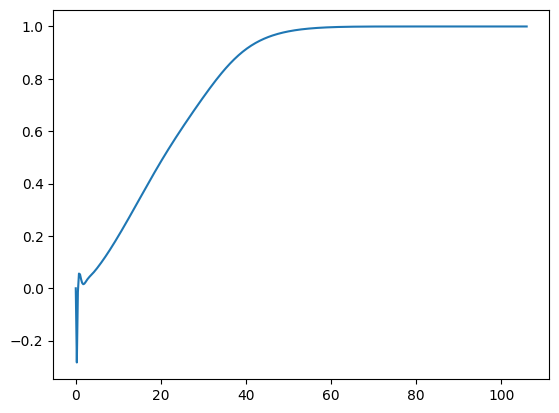

In [37]:
plt.plot(z_D[:Q], np.sum(D_A, axis=1))

In [38]:
N_D = int(t_D_max/dt_A) # maximum number of diffusion timesteps worth considering
D_t = np.moveaxis(cum_mat_prod(D_A,N_D),0,-1)
#D_t = np.moveaxis(cum_mat_prod(np.linalg.matrix_power(Dome_C.D,int(dt1/dt_D)),N_D),0,-1)
D_t.shape

100%|█████████████████████████████████████████████████████████████████████████████| 1999/1999 [00:01<00:00, 1295.41it/s]


(425, 425, 2000)

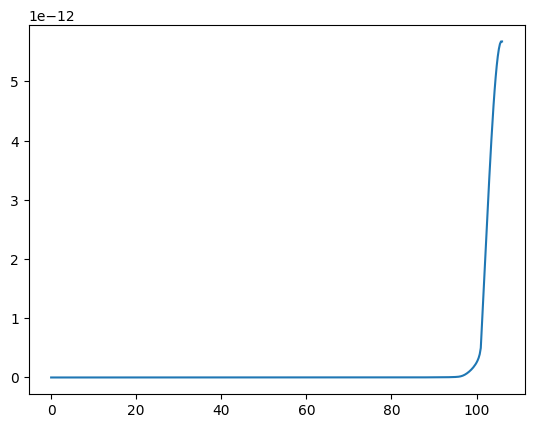

In [39]:
# after 1000 years only ~1e-12 of 14CO is left
plt.plot(z_D[:Q], np.sum(D_t[:Q,:,-1],axis=-1))

## Unit Conversions ($U$)

$$U_{g\rightarrow ppm}(z) = \frac{RT * 10^{18}}{N_A P \frac{s_o(z)}{\rho(z)} e^{M_{air} g z/(RT)} * 10^{-6}}$$

$$U_{ppm\rightarrow g}(z) = \frac{N_A P \frac{s_c(z)}{\rho(z)} b_p(z) * 10^{-6}}{RT * 10^{18}}$$

/tmp/ipykernel_2753/3435524479.py:1: RuntimeWarning: divide by zero encountered in divide
  gram_to_ppm = 1e18*R*T / (6.022140857e23*pressure*s_open/rho*np.exp(M_air*g*z_grid/(R*T))*1e-6)


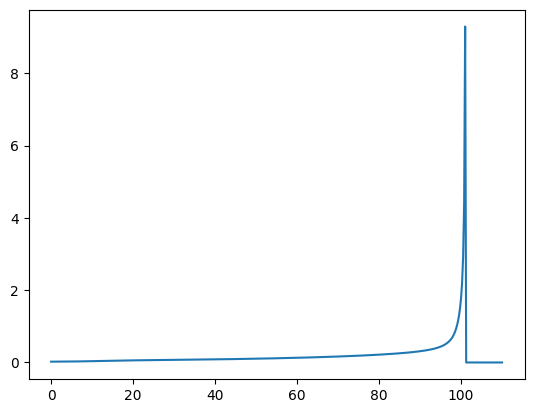

In [40]:
gram_to_ppm = 1e18*R*T / (6.022140857e23*pressure*s_open/rho*np.exp(M_air*g*z_grid/(R*T))*1e-6)
gram_to_ppm[teller_co:] = 0

#U = (gram_to_ppm * (delta_pa @ delta_ap @ s_open)/(delta_pa @ delta_ap @ s))[:Q]
#U = 1e18*R*T / (6.022140857e23*pressure*s[:Q]/rho[:Q]*np.exp(M_air*g*z[:Q]/(R*T))*1e-6)
plt.plot(z_grid, gram_to_ppm)

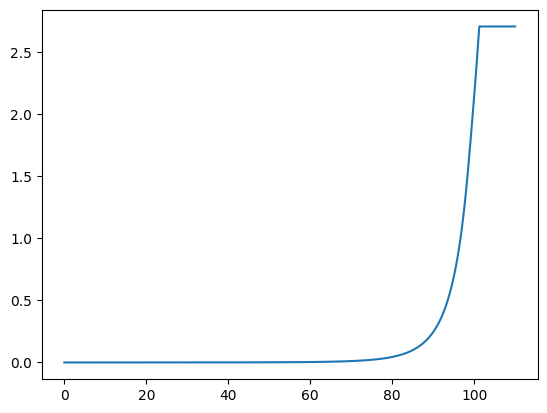

In [41]:
ppm_to_gram_cl = (6.022140857e23 * pressure * s_closed / rho * bubble_pres * 1e-6)/(1e18*R*T)
plt.plot(z_grid, ppm_to_gram_cl)

## Trapping Rate ($\text{tr}$)

The trapping rate of open porosity gas into closed porosity gas is given by the change in the number density of closed porsosity gas particles per unit time:

$$trapping(z) = \rho(z)\frac{d(s_c*b_p)}{dz}$$

Since all of these new gas particles entering the closed porosity of our ice parcel come from the open porosity, the additional $^{14}$CO concentration ($c(z)$) they bring is the integral over time of the open porosity concentration ($c_o(z,t)$) times the trapping rate ($tr(z)$) times the fraction of $^{14}$C which has since decayed ($e^{-\lambda (t-t')}$), divided by the total gas in closed porosity ($\int_{t_0}^t tr(z(t'))\,dt'$).

$$c(z,t) = \frac{\int_{t_0}^{t} c_o(z(t'),t')\,tr(z(t'))\,e^{-\lambda (t-t')}\,dt'}{\int_{t_0}^t tr(z(t'))\,dt'}$$

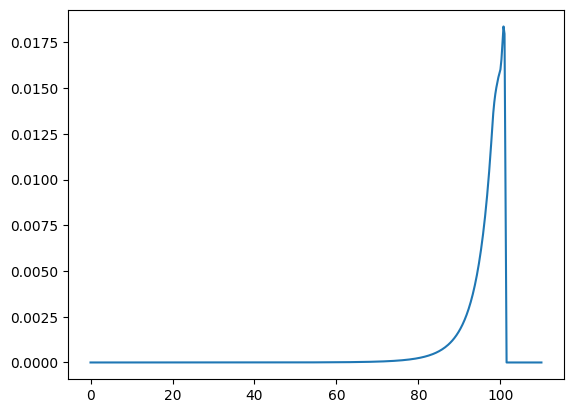

In [42]:
trapping_t = rho*smooth_diff(s_closed*bubble_pres/rho)/dz_grid # Acc*rho_ice/v_ice = Acc*rho_ice/(Acc*rho_ice/rho) = rho
plt.plot(z_grid, trapping_t)

# Accumulation Tensors ($\hat{A}$)

## Grains

$$\vec{c}^{\text{grains}}_f = \sum_{p,t,r}\hat{A}^{\text{grains}}_{f,p,t,r}\vec{P}_p\vec{\phi}_{t} \vec{R}_r$$

$\vec{P}_p$ - Production Rates [molecules g$^{-1}$ yr$^{-1}$], Total present-day in situ $^{14}$CO production rate at production depth $p$

$\vec{\phi}_t$ - CR History [unitless], flux of cosmic ray muons at production time $t$, relative to present ($t=0$)

$\vec{R}_r$ - Reservoir Partition [unitless], fraction of in situ $^{14}$CO partitioned into ice grain reservoir $r$

$\hat{A}^{\text{grains}}_{f,p,t,r}$ - Ice Grain Accumulation Tensor [yrs], Contribution to present-day $^{14}$CO concentration in ice grains at final depth $f$ from production depth $p$, production time $t$, and reservoir $r$

$$\hat{A}^{\text{grains}}_{f,p,t,r} = \vec{\Lambda}_r^{-t_A}dt_A\, \hat{\delta}_{f,a-t_A} \cdot \hat{\delta}_{a,p}\cdot \hat{\delta}_{t_A,t}$$

$\hat{\delta}_{t_A,t}$ - Interpolation matrix [unitless] from production time $t$ to accumulation time $t_A$, s.t. $t_A \approx t$

$\hat{\delta}_{a,p}$ - Interpolation matrix [unitless] from production depth $p$ to accumulation depth $a$, s.t. $h_a \approx h_p$

$\hat{\delta}_{f,a-t_A}$ - Interpolation matrix [unitless] from accumulation depth $a-t_A$ to final depth $f$, s.t. $z_f \approx z_{a-t_A} = z(\text{age}(z_a)-t_A)$

$\vec{\Lambda}_r = (1-\vec{L}_r) e^{-\lambda}$ - Ice grain loss rate [unitless], fraction of $^{14}$CO in reservoir $r$ lost to decay & leakage in one year

$\vec{L}_r$ - Annual leakage rate [unitless] of reservoir $r$

In [43]:
const = True # simplify calculation to assume constant CR flux
z_end = 120 # depth [m] where we switch from firn model to solid ice model

In [60]:
delta_fA = interp_mat(z_f[:,None],np.array([0,*z_A])[None,:])[:,1:]
delta_Ap = interp_mat(h_A[:,None],h_p[None,:])

f_end = np.arange(len(z_f))[z_f>z_grid[teller_co]][0]-1
A_end = np.arange(len(z_A))[z_A>z_grid[teller_co]][0]
p_end = np.arange(len(z_p))[z_p>z_grid[teller_co]][0]
t_start = np.arange(len(t_P))[t_P<-age_grid[teller_co]][-1]

t = -np.arange(A_end)-1
if const:
    A_grains_const = np.zeros((f_end, A_end, len(L)))
    for i in tqdm(t):
        A_grains_const[:,:i,:] += delta_fA[:f_end,-i:A_end,None] * (1-L[None,None,:])**(-i*dt_A)* np.exp(lambd*i*dt_A) * dt_A
    A_grains_const = delta_Ap[:A_end,:p_end].T @ A_grains_const
    A_grains_const.shape

100%|███████████████████████████████████████████████████████████████████████████████| 4409/4409 [00:49<00:00, 89.07it/s]


In [61]:
if not const:
    A_grains = np.zeros((f_end, A_end, len(t_P[t_start:]), len(L)))

    t_ratio = int(dt_P/dt_A)

    # for efficiency, we manually perform the dot product with delta_At
    for i in tqdm(t):
        j = int(i/t_ratio)
        k = (i%t_ratio+0.5)/t_ratio
        x = delta_fA[:f_end,-i:A_end,None] * (1-L[None,None,:])**(-i*dt_A)* np.exp(lambd*i*dt_A) * dt_A
        A_grains[:,:i,j,:] += x * (1-k)
        A_grains[:,:i,j+1,:] += x * k
    A_grains = np.einsum('fAtl, Ap -> fptl', A_grains, delta_Ap[:A_end,:p_end], optimize=True)
    A_grains.shape

/tmp/ipykernel_2753/603962047.py:19: RuntimeWarning: invalid value encountered in divide
  axes[1].plot(z_f[:f_end], np.einsum('fpl, p, l -> f', A_grains_const, P[:p_end], Res, optimize=True)/np.interp(z_f[:f_end], runMat['z'][:,0], runMat['C14_grains'][:,-1,1])-1)


[Text(0, 0.5, 'Relative to Matlab'), Text(0.5, 0, 'Depth [m]')]

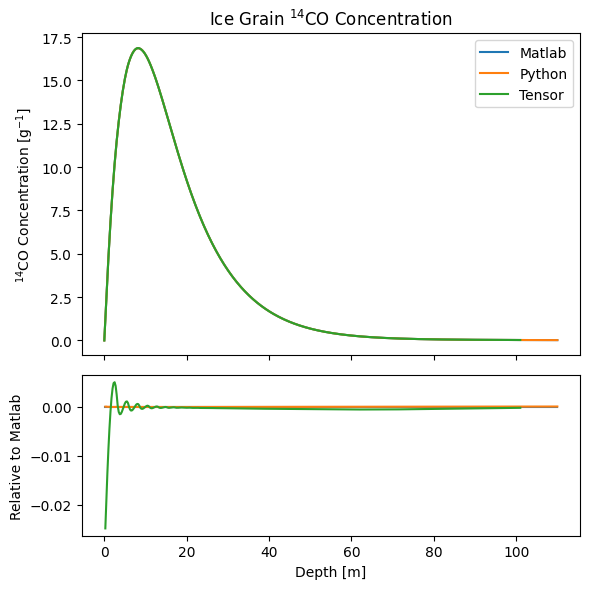

In [62]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

#plt.plot(z, np.einsum('lapt, t, p, l -> a', A_grains_full, phi, P, Res, optimize=True))
if Load_Mat:
    axes[0].plot(runMat['z'], runMat['C14_grains'][:,-1,1], label='Matlab')
if Copy_Firn:
    axes[0].plot(Site.z, P0_tuning @ C14_grains @ Res, label='Python')
if const:
    axes[0].plot(z_f[:f_end], np.einsum('fpl, p, l -> f', A_grains_const, P[:p_end], Res, optimize=True), label='Tensor')
else:
    axes[0].plot(z_f[:f_end], np.einsum('fptr, p, t, r -> f', A_grains, P[:p_end], phi[t_start:], Res, optimize=True), label='Tensor')
axes[0].legend()

if Load_Mat:
    axes[1].plot(runMat['z'][1:], runMat['C14_grains'][1:,-1,1]/runMat['C14_grains'][1:,-1,1]-1)
    if Copy_Firn:
        axes[1].plot(Site.z[1:], (P0_tuning @ C14_grains @ Res)[1:]/runMat['C14_grains'][1:,-1,1]-1)
    if const:
        axes[1].plot(z_f[:f_end], np.einsum('fpl, p, l -> f', A_grains_const, P[:p_end], Res, optimize=True)/np.interp(z_f[:f_end], runMat['z'][:,0], runMat['C14_grains'][:,-1,1])-1)

axes[0].set(
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=r'Ice Grain $^{14}$CO Concentration',
)

axes[1].set(
    ylabel='Relative to Matlab',
    xlabel='Depth [m]',
)

## Open Porosity

$$\vec{c}^{\text{open}}_{f} = \sum_{p,t,r} \hat{A}^{\text{open}}_{f,p,t,r}\vec{P}_{p}\vec{\phi}_{t}\vec{R}_r + \sum_{t}\hat{A}^{\text{atm}}_{f,t}\vec{C}^{\text{atm}}_{t_{atm}}$$

$\vec{c}^{\text{open}}_{f}$ - Predicted open porosity $^{14}$CO concentration [ppm] at final depth $f$

$\vec{C}^{\text{atm}}_{t_{atm}}$ - Atmospheric $^{14}$CO History [ppm], Concentration of $^{14}$CO in the atmosphere at time $t_{atm}$

$$\hat{A}^{\text{atm}}_{f,t_{atm}} = \hat{\delta}_{f,d}\cdot [\sum_{t_D=0}^{dt_A} D^{t_D}_{d,d'}]\cdot D^{-t_A}_{d',0} \cdot \hat{\delta}_{t_A,t_{atm}}$$

$\hat{A}^{\text{atm}}_{f,t_{atm}}$ - Open Porosity Atmospheric Accumulation Tensor [unitless], Contribution to present-day $^{14}$CO concentration in open porosity at final depth $f$ from atmospheric $^{14}$CO at time $t_{atm}$

$D^{t}_{d,d'}$ - Diffusion matrix [unitless], transforms open porosity $^{14}$CO concentration at initial diffusion depth $d'$ to new diffusion depth $d$ after duration $t$ of diffusion

$\hat{\delta}_{t_A,t_{atm}}$ - Interpolation matrix [unitless] from atmospheric time $t_{atm}$ to accumulation time $t_A$, s.t. $t_A \approx t_{atm}$

$\hat{\delta}_{f,d}$ - Interpolation matrix [unitless] from diffusion depth $d$ to final depth $f$, s.t. $z_f \approx z_d$

$$\hat{A}^{\text{open}}_{f,p,t,r} = [\sum_{t'=0}^{\text{age}_{co}} \hat{\mathcal{D}}_{f,a+t',-t_A-t'} \vec{\Lambda}_r^{t'}(1-\vec{l}_r^{dt'})]dt_A\cdot \hat{\delta}_{a,p} \cdot \hat{\delta}_{t_A,t}$$

$\hat{A}^{\text{open}}_{f,p,t,r}$ - Open Porosity In Situ Accumulation Tensor [yrs], Contribution to present-day $^{14}$CO concentration in open porosity at final depth $f$ from in situ $^{14}$CO at production depth $p$ and production time $t$ in reservoir $r$

$t'$ - Leak time; time spent in grain before leaking into open pores, from production ($t_A$) to leakage ($t_A+t'$), can't be longer than age at close-off depth

$a+t'$ - Leak depth; depth at which $^{14}$CO produced at depth $a$ leaks into open pores, $z^{acc}_{a+t'}=z(age(z^{acc}_a)+t')$

$-t_A-t'$ - Diffusion time; time spent diffusing in open porosity between leakage ($t_A+t'$) and measurement (0)

$\vec{\Lambda}_r = (1-\vec{L}_r) e^{-\lambda}$ - Ice grain loss rate [unitless], fraction of $^{14}$CO in reservoir $r$ lost to decay & leakage in one year

$\vec{l}_r = 1-\vec{L}_r$ - Fraction [unitless] of $^{14}$CO in ice grain reservoir $r$ that hasn't leaked after 1 year.  ($(1-\vec{l}_r^{dt'})$ is the fraction that HAS leaked after time $dt'$)

$\vec{L}_r$ - Annual leakage rate [unitless] of reservoir $r$

$\hat{\delta}_{t_A,t}$ - Interpolation matrix [unitless] from production time $t$ to accumulation time $t_A$, s.t. $t_A \approx t$

$\hat{\delta}_{a,p}$ - Interpolation matrix [unitless] from production depth $p$ to accumulation depth $a$, s.t. $h_a \approx h_p$

$$\hat{\mathcal{D}}_{f,a,t_A} = \hat{\delta}_{f,d}\cdot ([\sum_{t_D=0}^{dt_A} D^{t_D} \frac{dt_D}{dt_A}]\cdot D^{t_A})_{d,d'} U_{g\rightarrow ppm}(z_{d'})\frac{s_o(z_{d'})}{s(z_{d'})} \cdot \hat{\delta}_{d',a}$$

$\hat{\mathcal{D}}_{f,a,t_A}$ - $^{14}$CO Diffusion matrix from accumulation depth $a$ to final depth $f$ with a duration from $t_A$ to $t_A+dt_A$, subdivided into time steps of $t_D$, including a conversion from g to ppm and scaling by the open fraction of porosity.

$s_o(z)$ - Open porosity [unitless] at depth $z$

$s(z)$ - Total porosity [unitless] at depth $z$

$U_{g\rightarrow ppm}(z)$ - Unit conversion [g ppm] from molecules per gram to ppm at depth $z$

$\hat{\delta}_{f,d}$ - Interpolation matrix [unitless] from diffusion depth $d$ to final depth $f$, s.t. $z_f \approx z_d$

$\hat{\delta}_{d',a}$ - Interpolatino matrix [unitless] from accumulation depth $a$ to diffusion depth $d$, s.t. $z_d \approx z_a$

In [63]:
if z_D[0]>0:
    delta_fd = interp_mat(z_f[:,None],np.array([0,*z_D])[None,:])[:,1:]
else:
    delta_fd = interp_mat(z_f[:,None],z_D[None,:])
delta_Atatm = interp_mat(t_A[:,None],t_atm[None,:])
#A_open_atm = delta_fd[:f_end,:Q] @ (np.sum(cum_mat_prod(D,int(dt_A/dt_D)) * dt_D/dt_A, axis=0)[:,0] @ D_t[:,:,::-1]) * dt_A @ delta_At[-N_D:,-int(N_D*dt_A/dt_P):]
A_open_atm = delta_fd[:f_end,:Q] @ (np.sum(cum_mat_prod(D,int(dt_A/dt_D)), axis=0)[:,0] @ D_t[:,:,::-1]) @ delta_Atatm[-N_D:,-int(N_D*dt_A/dt_atm):]
#axis0 - final depth (f)
#axis1 - atmospheric time (t_atm)
A_open_atm.shape

100%|█████████████████████████████████████████████████████████████████████████████████| 49/49 [00:00<00:00, 1516.57it/s]


(405, 100)

In [64]:
if const:
    delta_da = interp_mat(z_D[:,None], np.array([0,*z_A])[None,:])[:,1:]
    # sum over t', with funky indexing to account for -t'-t''=diffusion time and p+At''=leak depth
    A_open_const = np.zeros((f_end, A_end, len(L)))

    U_d = np.interp(z_D[:Q], z_grid, gram_to_ppm * s_open / s.clip(min=1e-20))
    DU_const = delta_fd[:f_end,:Q] @ np.linalg.inv(np.identity(Q)-D) * U_d[None,:] @ delta_da[:Q,:A_end]

    dt1 = dt_A
    for t1 in tqdm(range(A_end)): #t2 = time spent in grains before leaking
        A_open_const[:,:A_end-t1,:] += DU_const[:,t1:,None] * (np.exp(-lambd*t1*dt1) * (1-L)**(t1*dt1))[None,None,:]
    A_open_const *= (1-(1-L)**dt1)[None,None,:] * dt_D
    A_open_const = delta_Ap[:A_end,:p_end].T @ A_open_const
    A_open_const.shape

100%|██████████████████████████████████████████████████████████████████████████████| 4409/4409 [00:43<00:00, 100.30it/s]


In [65]:
if not const:
    delta_da = interp_mat(z_D[:,None], np.array([0,*z_A])[None,:])[:,1:]

    i = np.arange(int(dt_A/dt_D))
    D_sum = np.sum(cum_mat_prod(D,int(dt_A/dt_D)) * dt_D/dt_A, axis=0)

    U_d = np.interp(z_D[:Q], z_grid, gram_to_ppm * s_open / s.clip(min=1e-20))

    DU = np.einsum('det, fd, ea -> fat', (D_sum.T @ D_t) * U_d[None,:,None], delta_fd[:f_end,:Q], delta_da[:Q,:A_end], optimize=True)
    #axis0 - final depth (f)
    #axis1 - accumulation depth (a)
    #axis2 - accumulation time (t_A)
    DU.shape

    # sum over t', with funky indexing to account for -t'-t''=diffusion time and p+At''=leak depth
    t_end = len(t_P[t_start:])
    A_open = np.zeros((f_end, A_end, t_end, len(L)))#,int(age[Q]/dt1)+N_D))
    #axis0 - final depth (f)
    #axis1 - accumulation depth (a)
    #axis2 - production time (t_P)
    #axis3 - reservoir (r)

    #DU_sum = np.sum(DU, axis=-1)
    delta_At = interp_mat(t_A[:,None], t_P[None,:])

    #A_add = np.zeros((f_end, A_end, N_D+t_ratio))
    t_ratio = int(dt_P/dt_A)
    t_scale = (np.arange(t_ratio)+0.5)/t_ratio
    t_scale = np.array([1-t_scale,t_scale]).T

    DU_ext = np.zeros((f_end, A_end, N_D+t_ratio*2))
    DU_ext[:,:,t_ratio:N_D+t_ratio] = DU[:,:,::-1]
    #axis0 - final depth (f)
    #axis1 - accumulation depth = leak depth - t'; range = 0 : z_co-t'
    #axis2 - diffusion time (max->min) = N_D + t_A + t'; range = 0 : N_D; t_A = diff_t -N_D - t'

    for j in tqdm(range(int(A_end/t_ratio))): #t1 = time spent in grains before leaking
        for i in range(t_ratio):
            t1 = j*t_ratio + i
            #A_open[:,:,:-t1 if t1>0 else None,:] += DU_sum[None,:,t1:] * (np.exp(-lambd*t1*dt_A) * (1-L)**(t1*dt_A))[:,None,None]
            #i = t1%t_ratio
            #j = int(t1/t_ratio)
            #A_add[:] = 0
            #A_add[:,t1:,i:min(N_D,A_end-t1)+i] = DU[:,t1:,A_end-t1::-1]
            x = (DU_ext[:,t1:,i:i+N_D+t_ratio].reshape((f_end,A_end-t1,-1,t_ratio))@t_scale)[...,None] * (np.exp(-lambd*t1*dt_A) * (1-L)**(t1*dt_A))[None,None,None,None,:]

        A_open[:,:A_end-t1,-j-int(N_D/t_ratio)-2:-j-1,:] += x[:,:,:,0]
        A_open[:,:A_end-t1,-j-int(N_D/t_ratio)-1:t_end-j,:] += x[:,:,:,1]
    A_open *= (1-(1-L)**dt_A)[None,None,None,:] * dt_A
    A_open = np.einsum('fatr, ap -> fptr', A_open, delta_Ap[:A_end,:p_end], optimize=True)

    A_open.shape

[Text(0, 0.5, 'Relative to Matlab'), Text(0.5, 0, 'Depth [m]')]

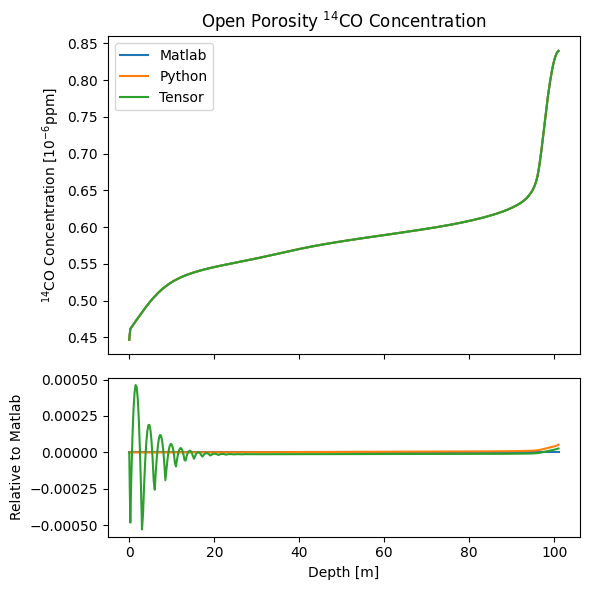

In [66]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

#plt.plot(z[:teller_co], (np.sum(A_open[:,:teller_co], axis=-1)@P[p<h[teller_co+1]]).T @ Res + A_open_atm[:teller_co] @ gas_history[-N_D:])
if Load_Mat:
    axes[0].plot(runMat['z'], runMat['c_open'][:,-1], label='Matlab')
if Copy_Firn:
    axes[0].plot(Site.z[:Site.teller_co], P0_tuning @ (c_gases[:Site.teller_co,1:].reshape(-1,3,2)) @ Res + c_gases[:Site.teller_co,0], label='Python')
if const:
    axes[0].plot(z_f[:f_end], P[:p_end] @ A_open_const @ Res + A_open_atm @ gas_history[-int(N_D*dt_A/dt_atm):], label='Tensor')
axes[0].legend()

#plt.plot(z[:teller_co], ((np.sum(A_open[:,:teller_co], axis=-1)@P[p<h[teller_co+1]]).T @ Res + A_open_atm[:teller_co] @ gas_history[-N_D:])/runMat['c_open'][:teller_co,-1]-1)
if Load_Mat:
    axes[1].plot(runMat['z'][:teller_co], runMat['c_open'][:teller_co,-1]/runMat['c_open'][:teller_co,-1]-1)
    if Copy_Firn:
        axes[1].plot(Site.z[:Site.teller_co], (P0_tuning @ (c_gases[:Site.teller_co,1:].reshape(-1,3,2)) @ Res + c_gases[:Site.teller_co,0])/runMat['c_open'][:teller_co,-1]-1)
    if const:
        axes[1].plot(z_f[:f_end], (P[:p_end] @ A_open_const @ Res + A_open_atm @ gas_history[-int(N_D*dt_A/dt_atm):])/np.interp(z_f[:f_end], runMat['z'][:,0], runMat['c_open'][:,-1])-1)

axes[0].set(
    ylabel=r'$^{14}$CO Concentration [$10^{-6}$ppm]',
    title=r'Open Porosity $^{14}$CO Concentration',
)

axes[1].set(
    ylabel='Relative to Matlab',
    xlabel='Depth [m]',
)

## Closed Porosity

$$\vec{c}^{\text{closed}}_{f} = \sum_{p,t,r} [\hat{A}^{\text{leak}} + \hat{A}^{\text{trap}}]_{f,p,t,r}\vec{P}_p\vec{\phi}_{t}\vec{R}_r + \sum_{t}\hat{A}^{\text{atm}}_{f,t}\vec{C}^{\text{atm}}_{t}$$

$\hat{A}^{\text{leak}}_{f,p,t,r}$ - 

$$\hat{A}^{\text{leak}}_{f,p,t,r} = e^{\lambda t_A}dt_A([\sum_{t'=0}^{-t_A}\frac{s_c(z_{a+t'})}{s(z_{a+t'})}\vec{l}_r^{t'}(1-\vec{l}_r^{dt'})] \hat{\delta}_{f,a-t_A})\cdot \hat{\delta}_{a,p} \cdot \hat{\delta}_{t_A,t}$$

$t'$ - leak time (relative to production)

In [67]:
dt1 = dt_A
t1 = np.arange(A_end)*dt_A
i = np.arange(A_end)
j = np.arange(len(t1))
sc_frac = np.interp(z_A[:A_end], z_grid, s_closed/s.clip(min=1e-20))
sc_cast = (sc_frac[(i[:,None]+j[None,:]).clip(max=A_end-1)]*(i[:,None]+j[None,:]<=A_end-1))
#axis0 - production depth (p)
#axis1 - grain time (t2)

t = np.arange(A_end)-A_end

closed_in = np.cumsum(
    sc_cast[:,:,None] * (1-L[None,None,:])**t1[None,:,None],
    axis=1
)[:,::-1,:] * (1-(1-L)**dt1)[None,None,:] * np.exp(lambd * t * dt_A)[None,:,None] * dt_A
#axis0 - Leakage rate (L)
#axis1 - production depth (p)
#axis2 - production time (t1)
closed_in.shape

(4409, 4409, 2)

In [68]:
if const:
    t = np.arange(A_end)-A_end
    A_closed_const = np.zeros((f_end, A_end, len(L)))
    for i in tqdm(t):
        A_closed_const[:,:i,:] += delta_fA[:f_end,-i:A_end,None] * closed_in[None,:i,i,:]
    A_closed_const = delta_Ap[:A_end,:p_end].T @ A_closed_const
    A_closed_const.shape

100%|███████████████████████████████████████████████████████████████████████████████| 4409/4409 [00:49<00:00, 88.45it/s]


/tmp/ipykernel_2753/258611037.py:16: RuntimeWarning: invalid value encountered in divide
  axes[1].plot(z_f[:f_end], P[:p_end] @ A_closed_const @ Res/np.interp(z_f[:f_end], runMat['z'][:,0], runMat['C14_closed'][:,-2,1])-1)


[Text(0, 0.5, 'Relative to Matlab'), Text(0.5, 0, 'Depth [m]')]

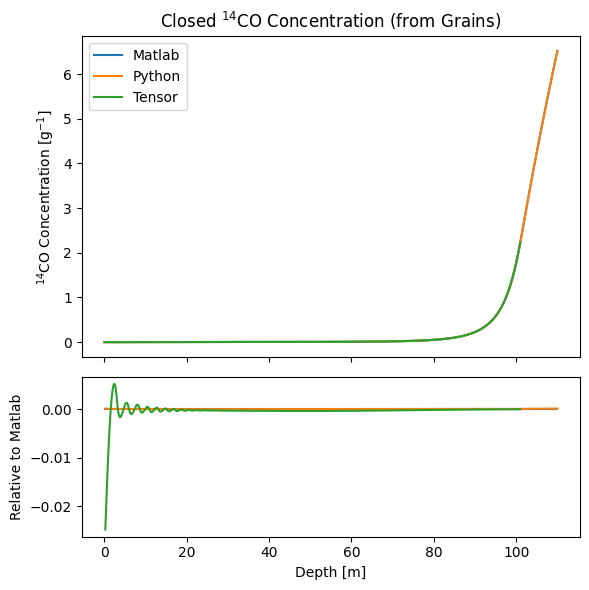

In [69]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

if Load_Mat:
    axes[0].plot(runMat['z'], runMat['C14_closed'][:,-2,1], label='Matlab')
if Copy_Firn:
    axes[0].plot(Site.z, P0_tuning @ (C14_cumuleak_closed) @ Res, label='Python')
if const:
    axes[0].plot(z_f[:f_end], P[:p_end] @ A_closed_const @ Res, label='Tensor')
axes[0].legend()

if Load_Mat:
    axes[1].plot(runMat['z'][1:], runMat['C14_closed'][1:,-2,1]/runMat['C14_closed'][1:,-2,1]-1)
    if Copy_Firn:
        axes[1].plot(Site.z[1:], (P0_tuning @ (C14_cumuleak_closed) @ Res)[1:]/runMat['C14_closed'][1:,-2,1]-1)
    if const:
        axes[1].plot(z_f[:f_end], P[:p_end] @ A_closed_const @ Res/np.interp(z_f[:f_end], runMat['z'][:,0], runMat['C14_closed'][:,-2,1])-1)

axes[0].set(
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=r'Closed $^{14}$CO Concentration (from Grains)',
)

axes[1].set(
    ylabel='Relative to Matlab',
    xlabel='Depth [m]',
    #ylim=(-0.002,0.002),
)

### Closed Porosity (Trapped)

$\hat{A}^{\text{atm}}$ - 

$$\hat{A}^{\text{atm}}_{f,t} = U_{ppm\rightarrow g}(z_f)\hat{\delta}_{f,a}\cdot(\sum_{t'=0}^{a}\frac{\text{tr}_{a-t'}}{\sum_{t''}^{a} \text{tr}_{t''}}e^{-\lambda t'} \hat{\mathcal{A}}^{\text{atm}}_{a-t',t_A-t'}) \cdot \hat{\delta}_{t_A,t}$$

$\hat{\mathcal{A}}^{\text{atm}}_{a,t_A} = \hat{\delta}_{a-t',d}\cdot[\sum_{t_D=0}^{dt_A} D^{t_D} \frac{dt_D}{dt_A}]_{d,d'}\cdot D^{-t_A-t'}_{d',0}\,dt_A$

$\hat{A}^{\text{trap}}$ - 

$$\hat{A}^{\text{trap}}_{f,p,t,r} = U_{ppm\rightarrow g}(z_f)\hat{\delta}_{f,a}\cdot(\sum_{t'=0}^{a}\frac{\text{tr}_{a-t'}}{\sum^a_{t''} \text{tr}_{t''}}e^{-\lambda t'}\hat{\mathcal{A}}^{\text{open}}_{a-t',p,t_A-t',r}) \cdot \hat{\delta}_{t_A,t}$$

$\hat{\mathcal{A}}^{\text{open}}_{a,p,t_A,r} = \hat{\delta}_{a,d}\cdot[\sum_{t''=0}^{\text{age}_{co}} \hat{\mathcal{D}}_{d,a'+t'',-t_A-t''} \vec{\Lambda}_r^{t''}(1-\vec{l}_r^{dt''})]dt_A\cdot \hat{\delta}_{a',p}$

$t'$ - time in closed grain after getting trapped

Note: I think $U_{ppm\rightarrow g}$ should be applied at trapping depth ($z_{a-t'}$), but in the firn model it is applied at final depth ($z_{f}$)

In [70]:
delta_Ad = interp_mat(z_A[:,None], np.array([0,*z_D])[None,:])[:,1:]
A_open_atm_A = delta_Ad[:A_end,:Q] @ (np.sum(cum_mat_prod(D,int(dt_A/dt_D)), axis=0)[:,0] @ D_t[:,:,::-1])
#axis0 - final depth (f)
#axis1 - atmospheric time (t_atm)
A_open_atm_A.shape

/tmp/ipykernel_2753/1175523987.py:6: RuntimeWarning: divide by zero encountered in divide
  slope = ((out[...,:-1 if out.shape[-1]>1 else None]-grid_in[...,:-1])/np.diff(grid_in,axis=-1)).clip(0,1)
100%|██████████████████████████████████████████████████████████████████████████████████| 49/49 [00:00<00:00, 797.58it/s]


(4409, 2000)

In [71]:
len(z_A)

4914

In [72]:
A_trap_atm = np.zeros((A_end, A_end+N_D))

trap_A = np.interp(z_A[:A_end], z_grid, trapping_t)
trap_sum = np.cumsum(trap_A*dt_A)

dt1 = dt_A
for t1 in tqdm(range(A_end)):
    A_trap_atm[t1:,t1:t1+N_D] += np.exp(-lambd*t1*dt1) * trap_A[:A_end-t1,None]/trap_sum[t1:,None] * A_open_atm_A[:A_end-t1,:] * dt1
A_trap_atm *= np.interp(z_A[:A_end], z_grid, ppm_to_gram_cl)[:,None]
A_trap_atm = delta_fA[:f_end,:A_end] @ A_trap_atm
A_trap_atm[:,A_end-1] += np.sum(A_trap_atm[:,len(z_A):],axis=-1)
A_trap_atm = A_trap_atm[:,:len(z_A)] @ delta_Atatm[-A_end-N_D:,-int((A_end+N_D)*dt_A/dt_atm):]
#axis0 - accumulation depth (a)
#axis1 - production time (t1)
A_trap_atm.shape

100%|███████████████████████████████████████████████████████████████████████████████| 4409/4409 [01:01<00:00, 71.99it/s]


(405, 245)

In [73]:
A_trap_const = np.zeros((A_end, p_end, len(L)))#, len(t1)+N_op))

trap_A = np.interp(z_A[:A_end], z_grid, trapping_t)
trap_sum = np.cumsum(trap_A*dt_A)

if z_f[0]>0:
    delta_Af = interp_mat(z_A[:,None], np.array([0,*z_f])[None,:])[:,1:]
else:
    delta_Af = interp_mat(z_A[:,None],z_f[None,:])
A_open_const_A = np.einsum('af, fpr -> apr', delta_Af[:A_end,:f_end], A_open_const, optimize=True)

dt1 = dt_A
for t1 in tqdm(range(A_end)):
    A_trap_const[t1:,:,:] += np.exp(-lambd*t1*dt1) * trap_A[:A_end-t1,None,None]/trap_sum[t1:,None,None] * A_open_const_A[:A_end-t1] * dt1
A_trap_const *= np.interp(z_A[:A_end], z_grid, ppm_to_gram_cl)[:,None,None]
A_trap_const = np.einsum('fa, apr -> fpr', delta_fA[:f_end,:A_end], A_trap_const, optimize=True)
#axis0 - Leakage rate (L)
#axis1 - accumulation depth (a)
#axis2 - production depth (p)
#axis3 - production time (t1)
A_trap_const.shape

100%|█████████████████████████████████████████████████████████████████████████████| 4409/4409 [00:02<00:00, 1583.44it/s]


(405, 66, 2)

[Text(0, 0.5, 'Relative to Matlab'), Text(0.5, 0, 'Depth [m]')]

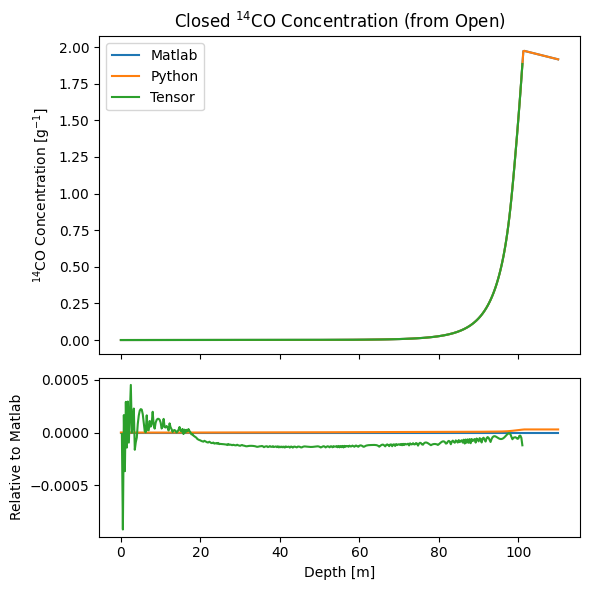

In [79]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

#plt.plot(z, Res @ np.sum(A_trap, axis=-1)@P + A_trap_atm @ gas_history)
if Load_Mat:
    axes[0].plot(runMat['z'], runMat['C14_closed'][:,-1,1]-runMat['C14_closed'][:,-2,1], label='Matlab')
if Copy_Firn:
    axes[0].plot(Site.z, P0_tuning @ (C14_closed_gas['C14_CO']) @ Res + C14_closed_atm['C14_CO'], label='Python')
if const:
    axes[0].plot(z_f[:f_end], P[:p_end] @ A_trap_const @ Res + A_trap_atm @ gas_history[-int((A_end+N_D)*dt_A/dt_atm):], label='Tensor')
axes[0].legend()

if Load_Mat:
    axes[1].plot(runMat['z'], (runMat['C14_closed'][:,-1,1]-runMat['C14_closed'][:,-2,1])/(runMat['C14_closed'][:,-1,1]-runMat['C14_closed'][:,-2,1])-1)
    if Copy_Firn:
        axes[1].plot(Site.z, (P0_tuning @ (C14_closed_gas['C14_CO']) @ Res + C14_closed_atm['C14_CO'])/(runMat['C14_closed'][:,-1,1]-runMat['C14_closed'][:,-2,1])-1)
    if const:
        axes[1].plot(z_f[1:f_end], (P[:p_end] @ A_trap_const @ Res + A_trap_atm @ gas_history[-int((A_end+N_D)*dt_A/dt_atm):])[1:]/np.interp(z_f[1:f_end], runMat['z'][:,0], runMat['C14_closed'][:,-1,1]-runMat['C14_closed'][:,-2,1])-1)

axes[0].set(
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=r'Closed $^{14}$CO Concentration (from Open)',
)

axes[1].set(
    ylabel='Relative to Matlab',
    xlabel='Depth [m]',
)

## Total $^{14}$CO Concentration & Production Uncertainty

$$\vec{c}^{pred}_s = \sum_{t',p} \hat{A}_{s,p,t'}\vec{P}_p\vec{\phi}_{t'} + \sum_{t}\hat{A}^{atm}_{s,t}\vec{C}_{t}^{atm}$$

$$\hat{A}_{s,p,t,r} = \hat{S}_{s,f}\cdot[\hat{A}^{grains}+\hat{A}^{closed}+\hat{A}^{trap}]_{f,p,t,r}$$

$$\hat{A}^{atm}_{s,t'} = \hat{S}_{s,f}\cdot \hat{A}^{atm}_{f,t}$$

$$\Sigma^{pred}_{ss'} = (\hat{A}\vec{\phi}\vec{R})_{s,p}\Sigma^{\vec{P}}_{p,p'}(\hat{A}\vec{\phi}\vec{R})^T_{p',s'} + (\hat{A}^{atm})_{s,t}\Sigma^{atm}_{t,t'}(\hat{A}^{atm})^T_{t',s'}$$

In [75]:
if const:
    A_profile = A_grains_const + A_closed_const + A_trap_const

[Text(0, 0.5, '% Relative to Matlab'), Text(0.5, 0, 'Depth [m]')]

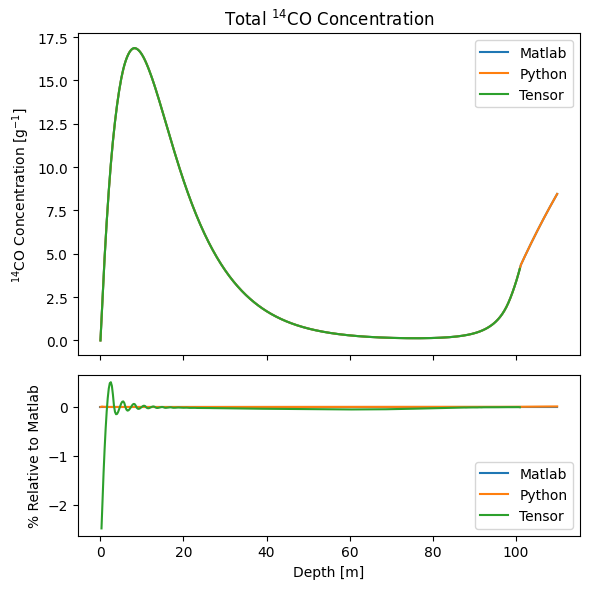

In [78]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

axes[0].plot(runMat['z'], runMat['C14_grains'][:,-1,1] + runMat['C14_closed'][:,-1,1], label='Matlab')
axes[0].plot(Site.z, P0_tuning @ (C14_grains + C14_cumuleak_closed + C14_closed_gas['C14_CO']) @ Res + C14_closed_atm['C14_CO'], label='Python')
axes[0].plot(z_f[:f_end], P[:p_end] @ A_profile @ Res + A_trap_atm @ gas_history[-int((A_end+N_D)*dt_A/dt_atm):], label='Tensor')
axes[0].legend()

axes[1].plot(runMat['z'], (runMat['C14_grains'][:,-1,1] + runMat['C14_closed'][:,-1,1])/(runMat['C14_grains'][:,-1,1] + runMat['C14_closed'][:,-1,1])*100-100, label='Matlab')
axes[1].plot(Site.z, (P0_tuning @ (C14_grains + C14_cumuleak_closed + C14_closed_gas['C14_CO']) @ Res + C14_closed_atm['C14_CO'])/(runMat['C14_grains'][:,-1,1] + runMat['C14_closed'][:,-1,1])*100-100, label='Python')
axes[1].plot(z_f[1:f_end], (P[:p_end] @ A_profile @ Res + A_trap_atm @ gas_history[-int((A_end+N_D)*dt_A/dt_atm):])[1:]/np.interp(z_f[:f_end], runMat['z'][:,0], runMat['C14_grains'][:,-1,1] + runMat['C14_closed'][:,-1,1])[1:]*100-100, label='Tensor')
axes[1].legend()

axes[0].set(
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=r'Total $^{14}$CO Concentration',
)

axes[1].set(
    ylabel='% Relative to Matlab',
    xlabel='Depth [m]',
)

### Extending Total Accumulation Tensor

$$\hat{A}_{f,p,t,r} = \begin{cases}
\hat{A}_{f,p,t,r} & f\leq f_{co}, p\leq p_{co}\\
\hat{A}_{f_{co},p,t',r}\cdot\hat{\delta}_{t',t+\Delta t}e^{-\lambda\Delta t} & f>f_{co}, p\leq p_{co}\\
[e^{\lambda t_A}dt_A\, \hat{\delta}_{f,a-t_A}\cdot \hat{\delta}_{a,p}] \cdot \hat{\delta}_{t_A,t} & f>f_{co}, p> p_{co}\\
0 & \text{else}
\end{cases}$$

$\Delta t = \text{age}(z_f)-\text{age}(z_{co})$

Works out much easier if $f$ is evenly spaced in ice age (at least below close-off depth)